In [1]:
using Plots

### Named Tuples

In [2]:
x = (a=1, b=2)
x.b

2

### Functions

In [3]:
f(x, y) = x + y

f (generic function with 1 method)

In [4]:
f(2, 4)

6

In [5]:
x -> x^2 +2x - 1

#3 (generic function with 1 method)

In [6]:
function (x)
    x^2 + 2x -1
end

#5 (generic function with 1 method)

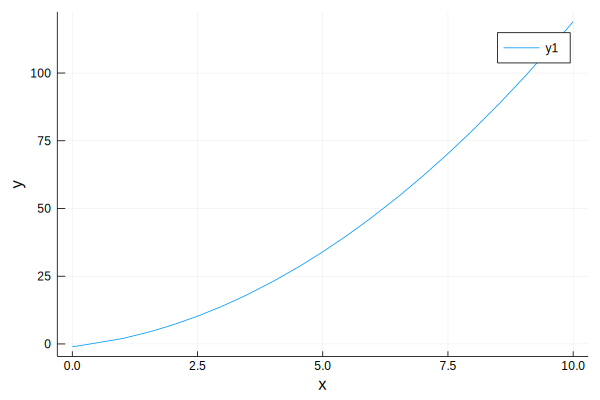

In [7]:
plot(x -> x^2 +2x - 1, 0, 10, xlabel="x", ylabel="y")

In [8]:
foo(x) = () -> x
bar = foo(1)
bar()

1

In [9]:
x, y, z = -1, -1, -1

(-1, -1, -1)

In [10]:
@show x y z

x = -1
y = -1
z = -1


-1

In [11]:
let x = 1, z
    @show x y z
end

x = 1
y = -1


UndefVarError: UndefVarError: z not defined

In [12]:
story = "This here is the wattle,\nthe emblem of our land.\n"
open("output.txt", "w") do f
    write(f, story)
end

49

### Control Flow

In [13]:
a = 150
a % 2 == 0 ? println("even") : println("odd")

even


In [14]:
function fact(n::Integer)
    n >= 0 || error("n cannot be negative")
    n == 0 && return 1
    n * fact(n - 1)
end

fact (generic function with 1 method)

**Tasks / Coroutines**

In [15]:
function fib(c::Channel)
    a = 0
    b = 1
    put!(c, a) # function pauses here until take!
    while true
        put!(c, b) # ...then pauses here...
        (a, b) = (b, a + b)
    end
end

fib (generic function with 1 method)

In [16]:
fibgen = Channel(fib)
take!(fibgen)

0

In [17]:
take!(fibgen)

1

In [18]:
take!(fibgen)

1

In [19]:
take!(fibgen), take!(fibgen), take!(fibgen), take!(fibgen)

(2, 3, 5, 8)

In [20]:
for val in Channel(fib)
    print(val, " ")
    val > 20 && break
end

0 1 1 2 3 5 8 13 21 

### Types
**Primitive**

In [21]:
primitive type Byte 8 end

In [22]:
Byte(val::UInt8) = reinterpret(Byte, val)

Byte

In [23]:
b = Byte(0x01)

Byte(0x01)

**Parametric Types**

In [24]:
struct Point{T <: Real}
    x::T
    y::T
end

In [25]:
Point(0., 0.)

Point{Float64}(0.0, 0.0)

In [26]:
Point(3, 4)

Point{Int64}(3, 4)

**Type Unions**

In [27]:
IntOrString = Union{Int64, String}
150::IntOrString

150

In [28]:
"Julia"::IntOrString

"Julia"

### Methods
**Parametric Methods**

In [29]:
isintpoint(p::Point{T}) where {T} = (T === Int64)

isintpoint (generic function with 1 method)

In [30]:
p = Point(1, 2)
isintpoint(p)

true

**Function-like Objects (Functors)**

In [31]:
struct Polynomial{R}
    coeff::Vector{R}
end

In [32]:
function (p::Polynomial)(x)
    val = p.coeff[end]
    for coef in p.coeff[end - 1:-1:1]
        val = val * x + coef
    end
    val
end

In [33]:
p = Polynomial([1, 10, 100])

Polynomial{Int64}([1, 10, 100])

In [34]:
p(1) # 1*1^0 + 10*1^1 + 100*1^2

111

In [35]:
p(3) # 1*3^0 + 10*3^1 + 100*3^2

931

In [36]:
@assert p(4) == 16*100 + 4*10 + 1

### Constructors

In [37]:
Point(1, 2) # implicit T

Point{Int64}(1, 2)

In [38]:
Point{Int64}(1, 2) # explicit T

Point{Int64}(1, 2)

In [39]:
struct Point{T <: Real}
    x::T
    y::T
    # Inner Constructor
    Point{T}(x, y) where {T <: Real} = new(x, y)
end

In [40]:
# Outer Constructor
Point(x::T, y::T) where {T <: Real} = Point{T}(x, y)

Point

In [41]:
Point(x::Real, y::Real) = Point(promote(x, y)...)

Point

In [42]:
p = Point(1, 2.3)

Point{Float64}(1.0, 2.3)

### Conversion and Promotion

In [43]:
x = 12
typeof(x)

Int64

In [45]:
xui = convert(UInt8, x)

0x0c

In [46]:
typeof(xui)

UInt8

In [47]:
# Custom convert
Base.convert(::Type{Point{T}}, x::Array{T, 1}) where {T <: Real} = 
    Point(x...)

In [48]:
convert(Point{Int64}, [1, 2])

Point{Int64}(1, 2)

In [49]:
promote(1, 2.5, 3)

(1.0, 2.5, 3.0)

### Metaprogramming

In [51]:
prog = "1 + 2"
expr = Meta.parse(prog)

:(1 + 2)

In [52]:
typeof(expr)

Expr

In [53]:
dump(expr)

Expr
  head: Symbol call
  args: Array{Any}((3,))
    1: Symbol +
    2: Int64 1
    3: Int64 2


In [54]:
expr = :(1 + 2)

:(1 + 2)

In [55]:
expr = quote 
    1 + 2
end

quote
    #= In[55]:2 =#
    1 + 2
end

In [57]:
typeof(expr)

Expr

In [58]:
eval(expr)

3

In [60]:
macro containervariable(container, element)
    return esc(:($(Symbol(container, element)) = $container[$element]))
end

@containervariable (macro with 1 method)

In [62]:
@containervariable letters 1

UndefVarError: UndefVarError: letters not defined

In [63]:
@generated function square(x)
    println(x)
    :(x * x)
end

square (generic function with 1 method)

In [64]:
x = square(4)

Int64Int64

ErrorException: task switch not allowed from inside staged nor pure functions

### Missing Values

In [1]:
a = [1, missing]

2-element Array{Union{Missing, Int64},1}:
 1       
  missing

In [2]:
sum(a)

missing

In [3]:
sum(skipmissing(a))

1

### Calling C and Fortran Code

In [4]:
Base.close(dbm::DBM) = gdbm_close(dbm.handle)

function gdbm_close(handle::Ptr{Cvoid})
    ccall((:gdbm_close, "libgdbm"), Cvoid, (Ptr{Cvoid},), handle)
end

UndefVarError: UndefVarError: DBM not defined